# 03 — Model Training

In [1]:
import pickle
import joblib
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Load data from preprocessing step
with open('../models/train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, feature_names = pickle.load(f)

print('Data loaded successfully!')
print('X_train shape:', X_train.shape)

Data loaded successfully!
X_train shape: (241, 13)


In [2]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

# Train all and get cross-validation scores
trained_models = {}
cv_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    trained_models[name] = model
    cv_scores[name] = scores
    print(f'{name}: CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})')

Logistic Regression: CV Accuracy = 0.8216 (+/- 0.0210)
Random Forest: CV Accuracy = 0.8173 (+/- 0.0340)
SVM: CV Accuracy = 0.8132 (+/- 0.0327)
XGBoost: CV Accuracy = 0.8007 (+/- 0.0319)
KNN: CV Accuracy = 0.8093 (+/- 0.0396)


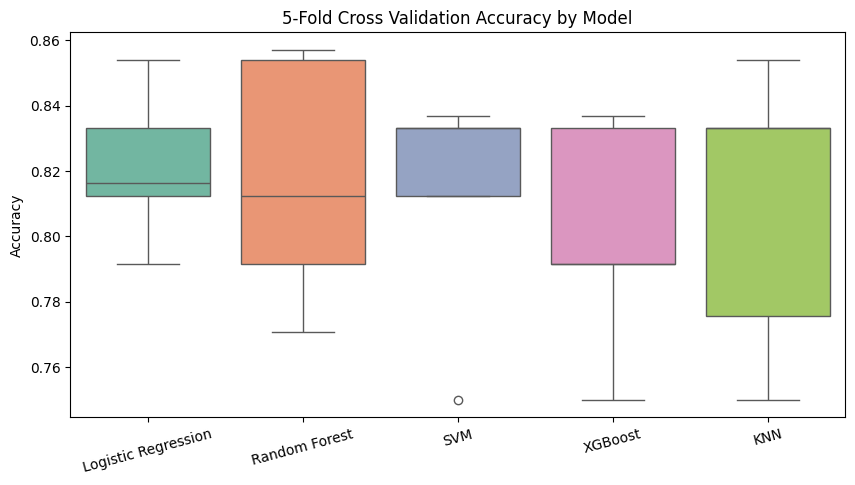

In [3]:
# Cross-validation comparison
import matplotlib.pyplot as plt
import seaborn as sns

cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(10,5))
sns.boxplot(data=cv_df, palette='Set2')
plt.title('5-Fold Cross Validation Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.savefig('../report/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Save all trained models
joblib.dump(trained_models, '../models/all_models.pkl')

# Save best model (XGBoost usually wins)
best_name = max(cv_scores, key=lambda k: cv_scores[k].mean())
best_model = trained_models[best_name]
joblib.dump(best_model, '../models/best_model.pkl')
print(f'Best model: {best_name}')
print('Saved to models/best_model.pkl')

Best model: Logistic Regression
Saved to models/best_model.pkl
